In [1]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/wind_extraction_mini_june_2025.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)

In [4]:
results["classification"] = results.Score.map(
    {
        10675893: "Correct (DNE)",
        7592334: "Correct (exists)",
        14791492: "Intern value wrong, LLM correct",
        13463000: "Intern value wrong, LLM wrong also",
        931198: "Value does not exist but LLM reported it",
        3305961: "Value exists but LLM did not find",
        238: "Value exists but LLM got it wrong",
        49407: "Bad web scrape",
    }
)
results["classification"].value_counts()

classification
Correct (DNE)                               265
Correct (exists)                            135
Value exists but LLM did not find            50
Bad web scrape                               25
Intern value wrong, LLM correct              11
Value exists but LLM got it wrong             7
Value does not exist but LLM reported it      5
Intern value wrong, LLM wrong also            2
Name: count, dtype: int64

In [5]:
correct_doc_compare = results[
    results["classification"] != "Bad web scrape"
].copy()

In [6]:
correct_doc_compare["ordinance_value_exists"] = (
    correct_doc_compare["Score"].apply(
        lambda x: int(x in {7592334, 14791492, 13463000, 3305961, 238})
    )
)

# A few manual adjustments
correct_doc_compare.loc[
    (correct_doc_compare["county"] == "Bureau")
    & (correct_doc_compare["feature"] == "property line (participating)"),
    ["ordinance_value_exists", "Score"]
] = [0, 10675893]
correct_doc_compare.loc[
    (correct_doc_compare["county"] == "Bureau")
    & (correct_doc_compare["feature"] == "transmission"),
    ["ordinance_value_exists", "Score"]
] = [0, 10675893]
correct_doc_compare.loc[
    (correct_doc_compare["county"] == "Norman")
    & (correct_doc_compare["feature"] == "noise"),
    ["ordinance_value_exists", "Score"]
] = [0, 10675893]
correct_doc_compare.loc[
    (correct_doc_compare["county"] == "Rockingham")
    & (correct_doc_compare["feature"] == "special use districts"),
    ["ordinance_value_exists", "Score"]
] = [0, 10675893]

In [7]:
score_cats = {
    "dne_no_report": {10675893},
    "exists_report": {7592334, 14791492},
    "dne_report": {931198},
    "exists_bad_report": {13463000, 238},
    "exists_no_report": {3305961},
}

llm_score = {
    10675893: 0,  # (0, 0) "Correct (DNE)",
    7592334: 1,   # (1, 1) "Correct (exists)",
    14791492: 1,  # (1, 1) "Intern value wrong, LLM correct",
    13463000: 2,  # (1, 0) "Intern value wrong, LLM wrong also",
    931198: 1,    # (0, 1) "Value does not exist but LLM reported it",
    3305961: 0,   # (1, 0) "Value exists but LLM did not find",
    238: 2,       # (1, 0) "Value exists but LLM got it wrong",

}

correct_doc_compare["llm_score"] = (
    correct_doc_compare["Score"].map(llm_score)
)

In [8]:
truth_labels_col = "ordinance_value_exists"
score_col = "llm_score"

out = compute_stats(
    correct_doc_compare,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[143  58]
 [  5 269]]
accuracy=86.74%, precision=91.67%, recall=71.14%, F1=80.11%


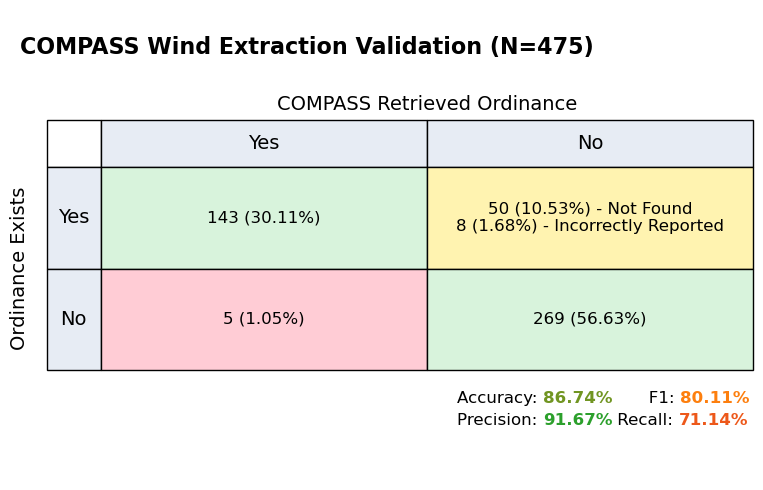

In [9]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare,
    score_cats,
    title="COMPASS Wind Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "wind_validation_all_ordinances.png",
    color_scores=True,
)

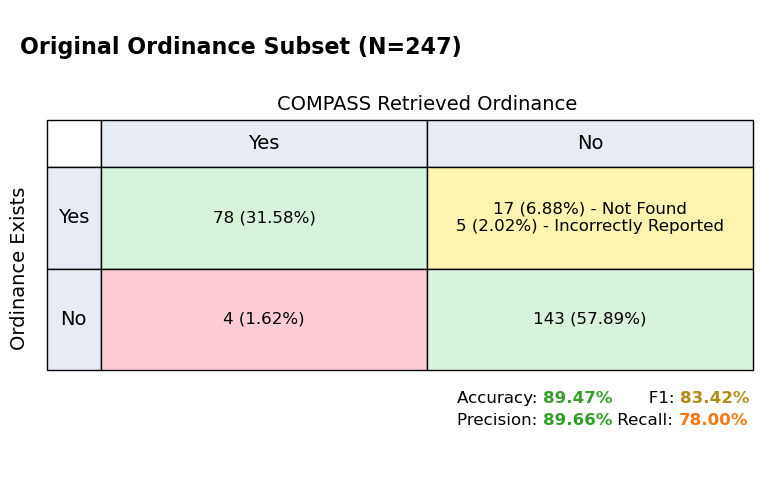

In [10]:
original_feats = {
    "structures (participating)",
    "structures (non-participating)",
    "property line (participating)",
    "property line (non-participating)",
    "roads",
    "railroads",
    "transmission",
    "water",
    "noise",
    "maximum height",
    "minimum lot size",
    "shadow flicker",
    "tower density",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[correct_doc_compare["feature"].isin(original_feats)],
    score_cats,
    title="Original Ordinance Subset",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "wind_validation_original_subset.png",
    color_scores=True,
)

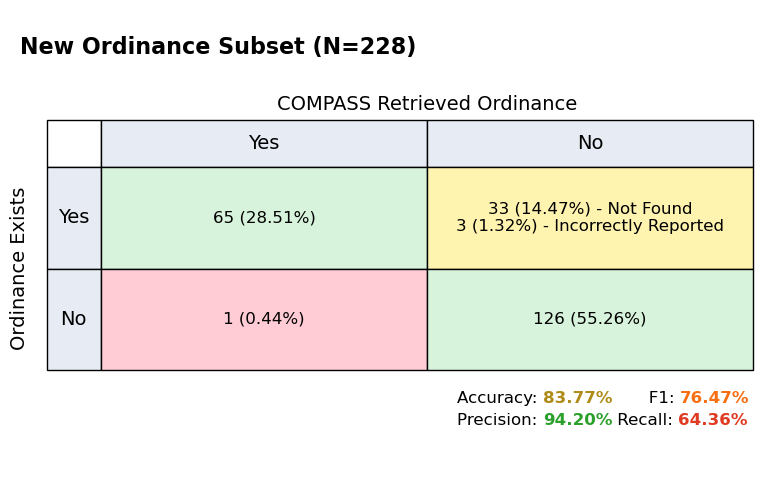

In [11]:
original_feats = {
    "structures (participating)",
    "structures (non-participating)",
    "property line (participating)",
    "property line (non-participating)",
    "roads",
    "railroads",
    "transmission",
    "water",
    "noise",
    "maximum height",
    "minimum lot size",
    "shadow flicker",
    "tower density",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[~correct_doc_compare["feature"].isin(original_feats)],
    score_cats,
    title="New Ordinance Subset",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "wind_validation_new_subset.png",
    color_scores=True,
)

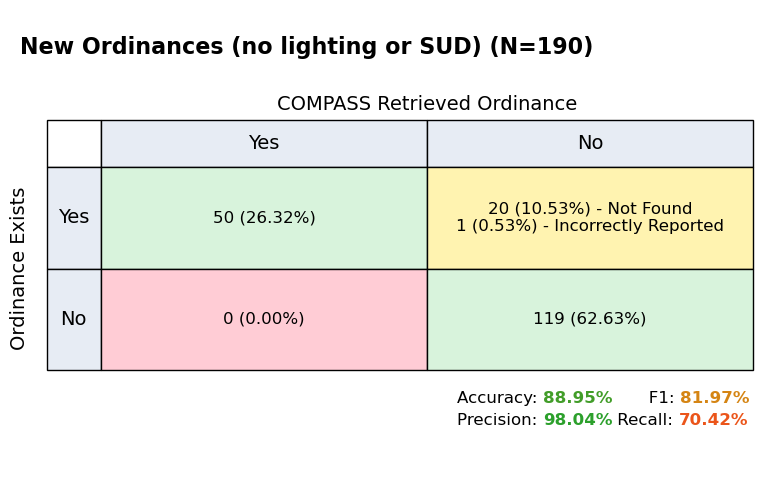

In [12]:
exclude_feats = {
    "structures (participating)",
    "structures (non-participating)",
    "property line (participating)",
    "property line (non-participating)",
    "roads",
    "railroads",
    "transmission",
    "water",
    "noise",
    "maximum height",
    "minimum lot size",
    "shadow flicker",
    "tower density",
    "lighting",
    "special use districts",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[~correct_doc_compare["feature"].isin(exclude_feats)],
    score_cats,
    title="New Ordinances (no lighting or SUD)",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "wind_validation_new_subset_no_lsu.png",

    color_scores=True,
)

In [13]:
all_stats = []
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data["ordinance_value_exists"].sum()
    num_found = (data["llm_score"] > 0).sum()
    num_found_correctly = (data["Score"].isin({7592334, 14791492})).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,structures (participating),94.736842,100.000000,83.333333,6,5,5
1,structures (non-participating),94.736842,100.000000,94.444444,18,17,17
2,property line (participating),89.473684,50.000000,50.000000,2,2,1
3,property line (non-participating),57.894737,64.285714,52.941176,17,14,9
4,roads,78.947368,92.307692,80.000000,15,13,12
5,railroads,100.000000,100.000000,100.000000,4,4,4
6,transmission,89.473684,100.000000,75.000000,8,6,6
7,water,94.736842,100.000000,83.333333,6,5,5
8,noise,84.210526,100.000000,76.923077,13,10,10
9,maximum height,100.000000,100.000000,100.000000,3,3,3


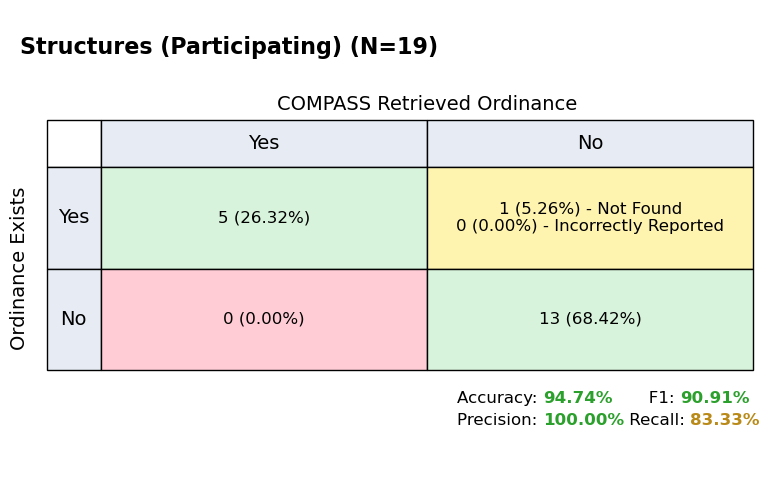

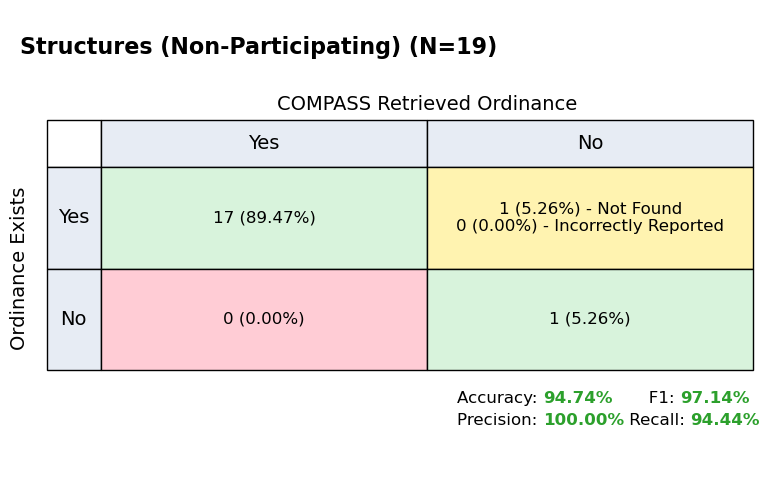

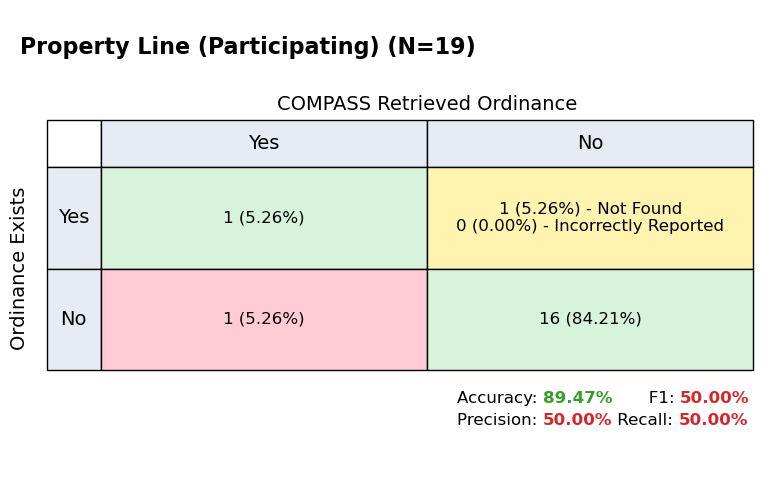

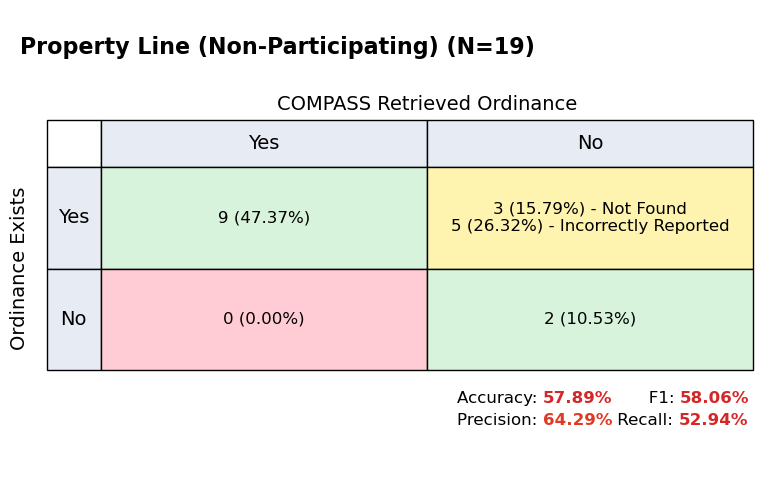

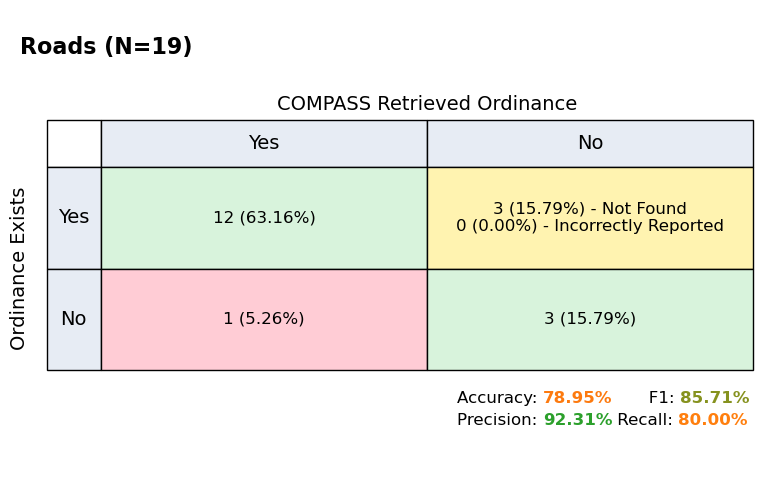

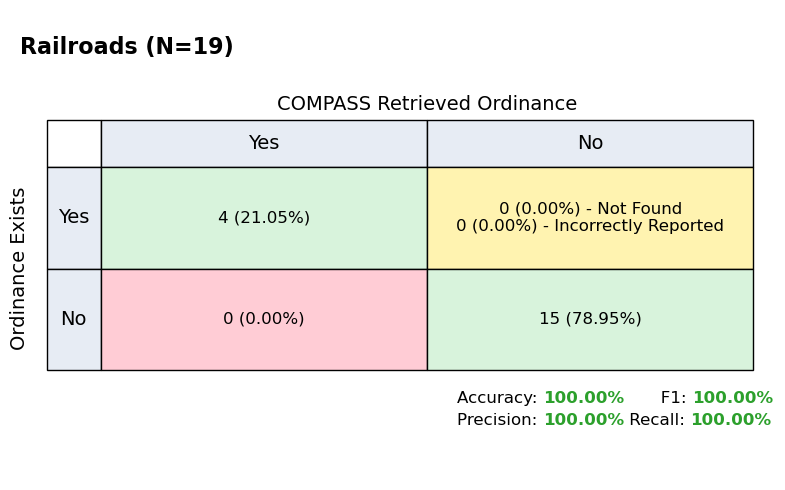

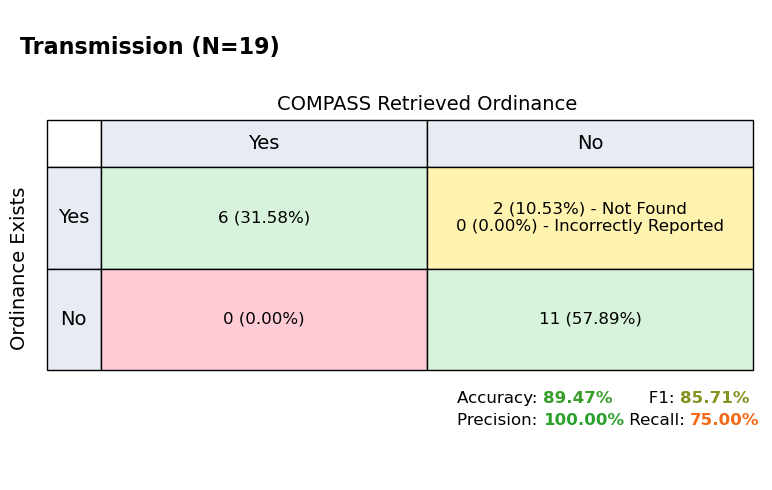

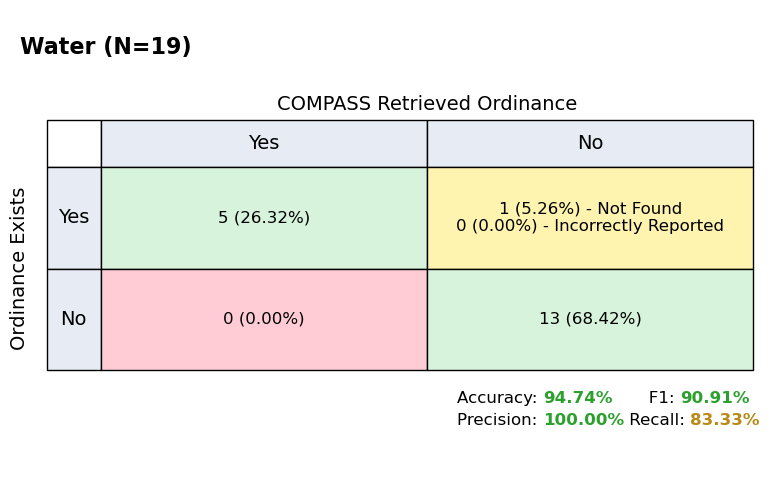

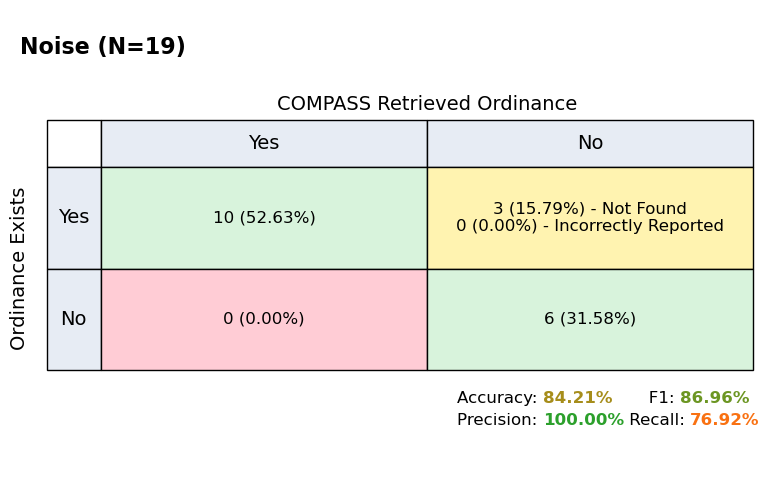

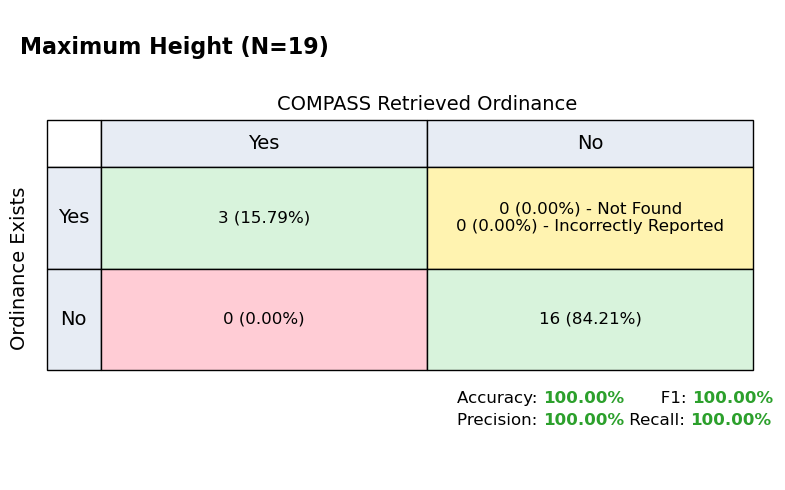

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


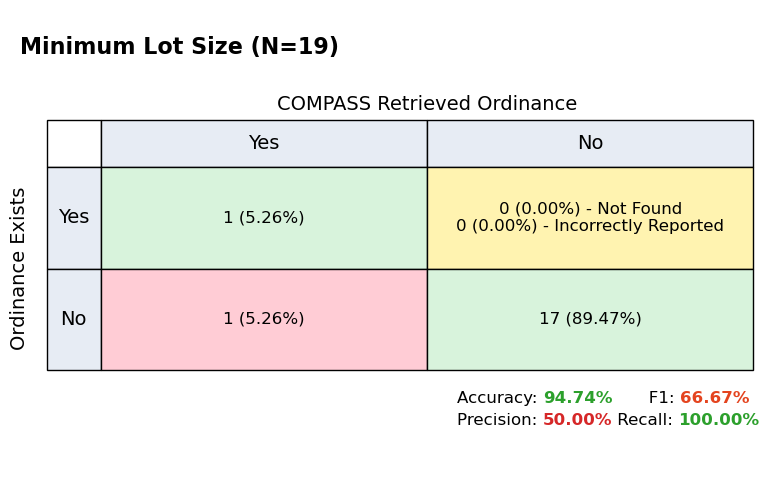

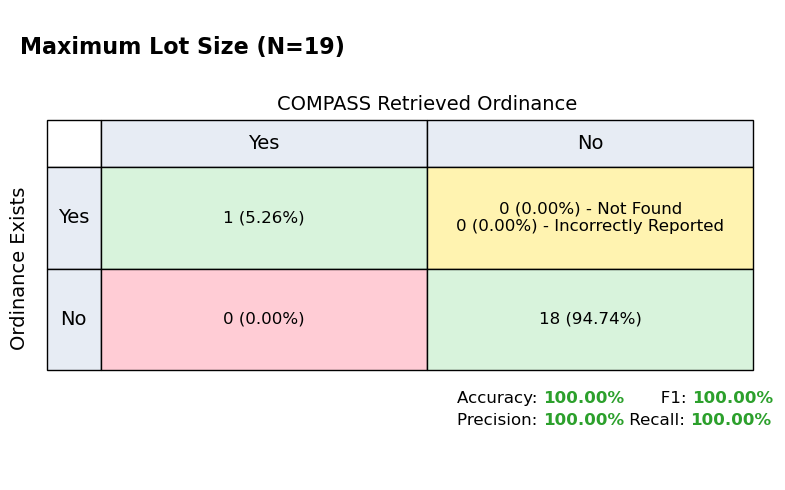

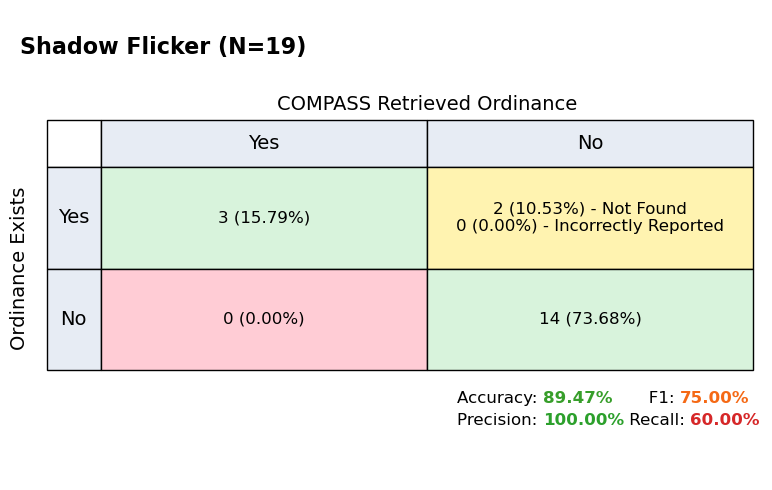

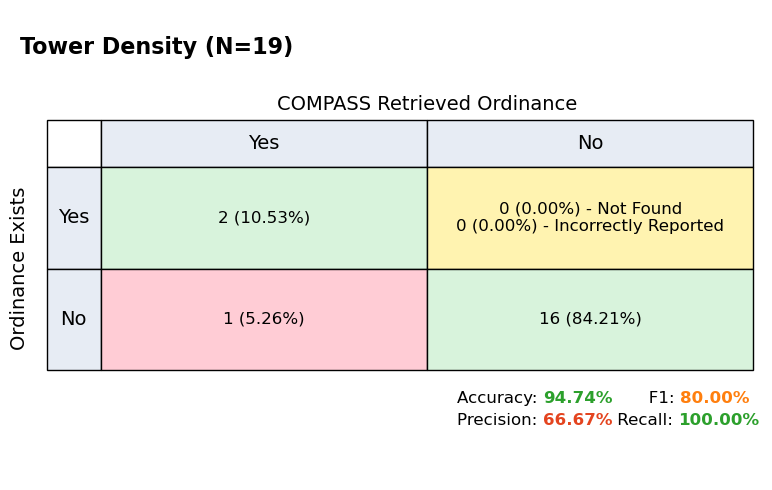

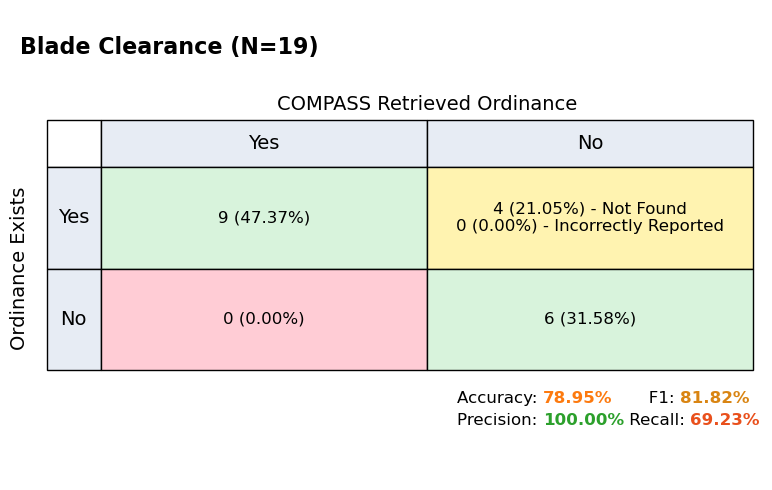

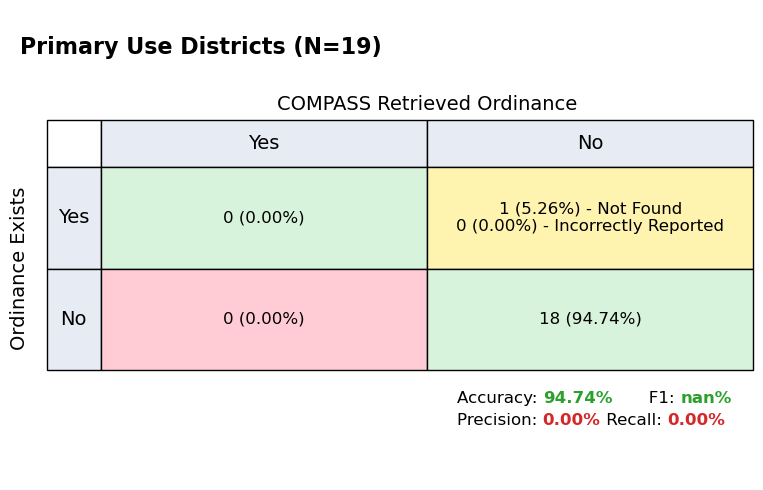

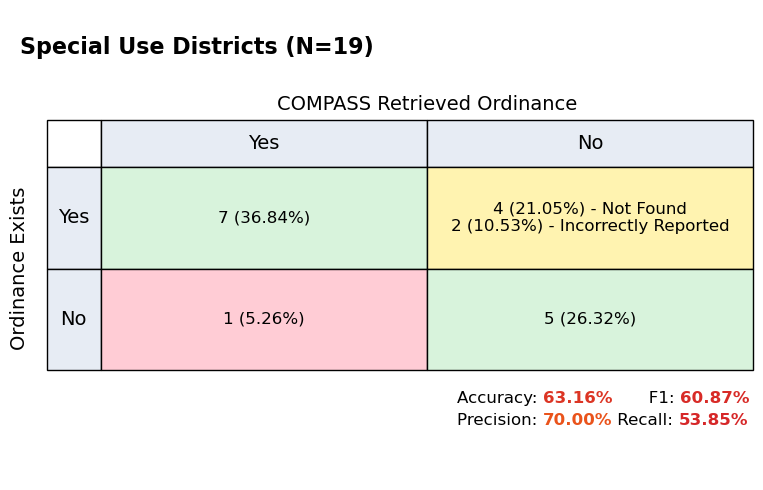

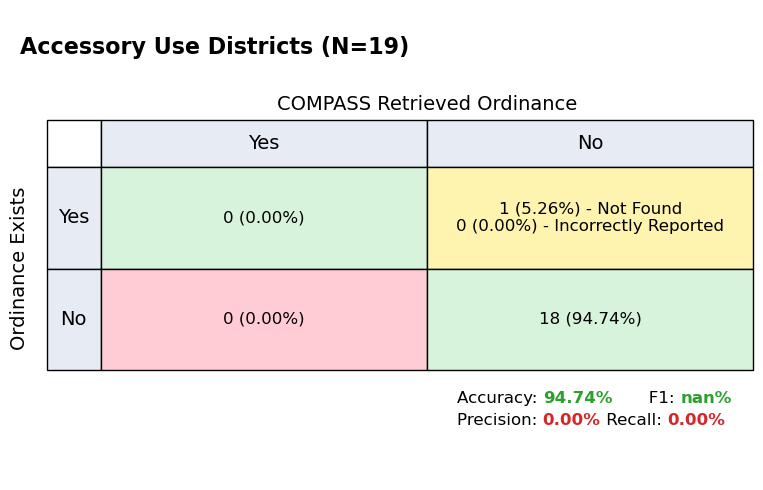

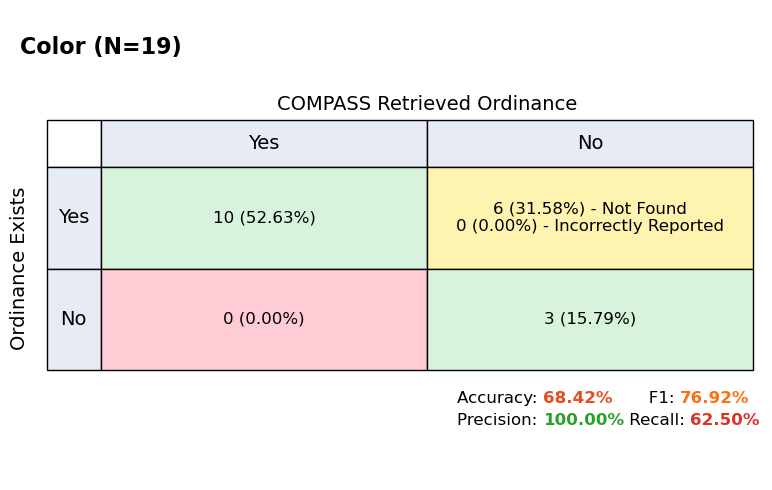

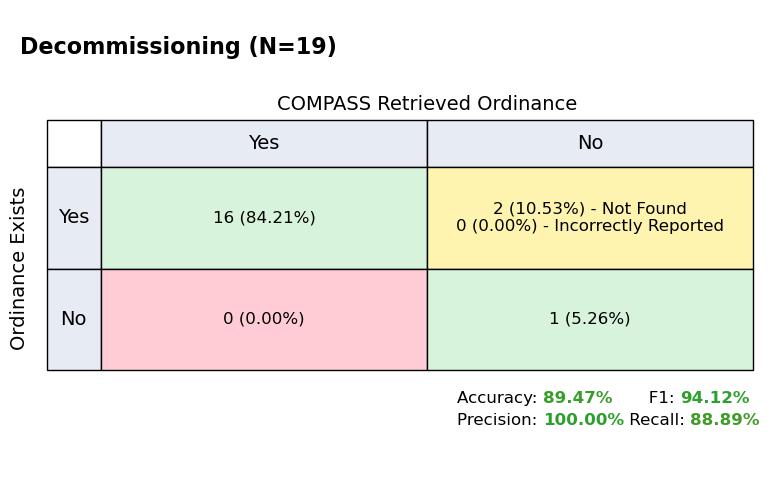

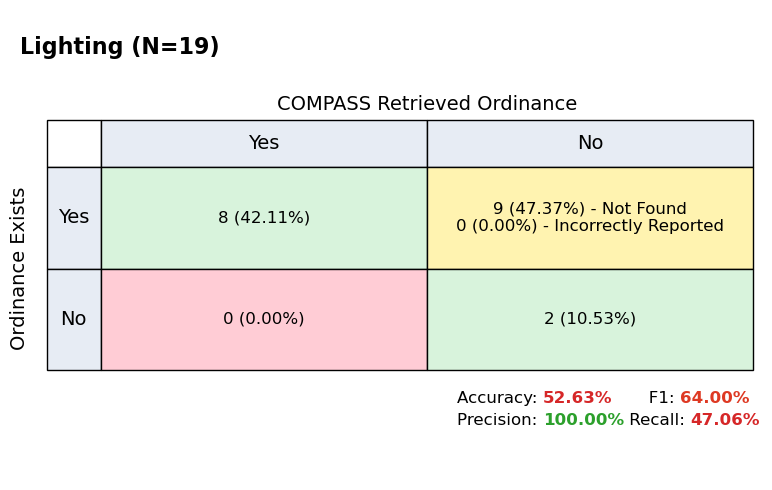

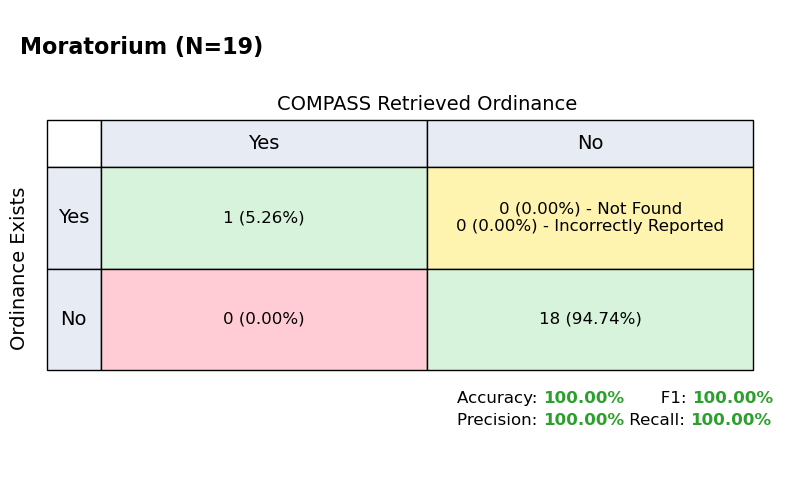

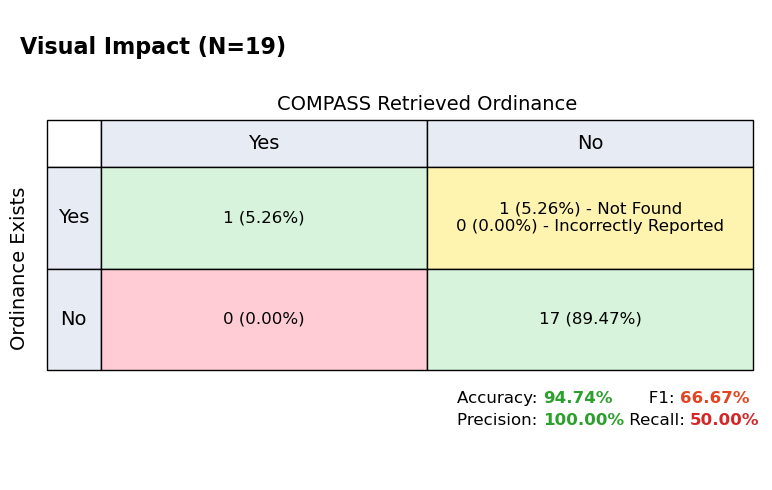

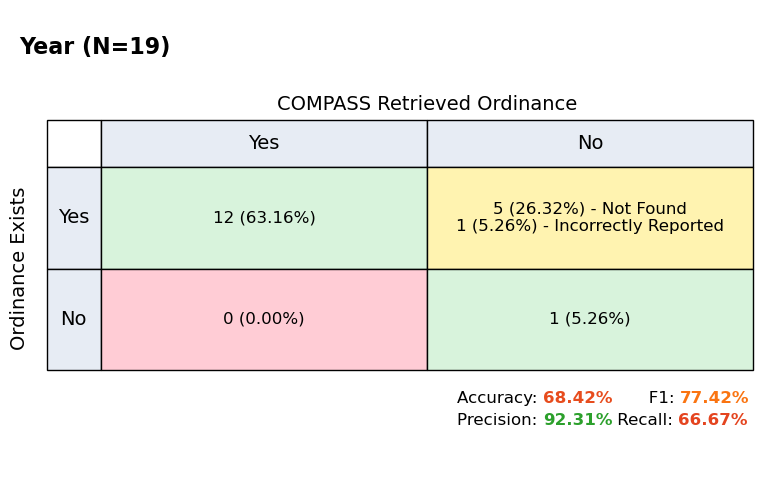

In [17]:
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    plot_out_fn = f"wind_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn.replace(" ", "_").replace("(", "").replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )